# Ejercicio Integrador — Rating, Sentimiento y Perfil de Viajero
 
Una cadena de hoteles quiere entender qué hace que una estadía sea buena o mala, más allá del promedio de estrellas. Tienen 340 reseñas de sus hoteles, con el texto completo de cada reseña y datos de quién la escribió. Se pide un análisis que combine el rating, el texto y el perfil del viajero para producir conclusiones accionables.
 
## Dataset
 
`reviews_hoteles.csv` — 340 filas, 8 columnas:
 
| Columna | Descripción |
|---|---|
| `fecha` | Fecha de la reseña |
| `hotel` | Nombre del hotel |
| `ciudad` | Ciudad donde está el hotel |
| `categoria_hotel` | Categoría oficial del hotel, en estrellas (1 a 5, fija por hotel) |
| `rating_usuario` | Puntuación que el huésped le dio a su estadía (1 a 5) |
| `review` | Texto de la reseña |
| `motivo_viaje` | Negocios, Familia, Pareja, Amigos o Solo |
| `procedencia` | País de origen del huésped |

In [3]:
import pandas as pd
import numpy as np

# Usamos read_csv para leer el archivo
datos = pd.read_csv('reviews_hoteles.csv')

# Una vez cargado, puedes ver las primeras filas para confirmar que funcionó
print(datos.head())

        fecha                    hotel         ciudad  categoria_hotel  \
0  2025-10-01         Hotel Costa Azul  Mar del Plata                3   
1  2025-10-01         Hotel Faro Viejo  Puerto Madryn                3   
2  2025-10-01           Posada del Sol          Salta                3   
3  2025-10-03         Gran Hotel Andes      Bariloche                5   
4  2025-10-03  Boutique Palermo Suites   Buenos Aires                4   

   rating_usuario                                             review  \
0               3  La habitación era correcta, el check-in tardó ...   
1               5  El desayuno fue espectacular, variedad y muy b...   
2               1  Wifi prácticamente inexistente durante toda la...   
3               2  Wifi prácticamente inexistente durante toda la...   
4               4  Excelente atención del personal, superó todas ...   

  motivo_viaje procedencia  
0      Familia    Colombia  
1      Familia       Chile  
2       Pareja      España  
3     

## Consigna
 
1. **EDA sobre rating.** Explorar la distribución de `rating_usuario` y compararla contra `categoria_hotel`. ¿Los hoteles de más estrellas tienen, en promedio, mejor rating de usuario?

In [4]:
import pandas as pd

# 1. Cargamos el archivo y le asignamos exactamente el nombre 'df' (DataFrame)
df = pd.read_csv('reviews_hoteles.csv')

# 2. Ahora sí calculamos los promedios, porque 'df' ya existe en esta celda
print("Promedio de categoria hotel: ", df["categoria_hotel"].mean())
print("Promedio de ratings de usuarios: ", df["rating_usuario"].mean())
print("----")



print(df["rating_usuario"].value_counts().sort_index())
print(df["categoria_hotel"].value_counts().sort_index())


Promedio de categoria hotel:  3.55
Promedio de ratings de usuarios:  3.45
----
rating_usuario
1     39
2     44
3     60
4    119
5     78
Name: count, dtype: int64
categoria_hotel
2     35
3    138
4    112
5     55
Name: count, dtype: int64


2. **Análisis de sentimiento.** Usar una herramienta de NLP ya entrenada para español (no entrenar ningún modelo propio) para clasificar cada `review` como positiva, negativa o neutra.

In [5]:
%pip install pysentimiento

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
# Tu codigo acá

import pandas as pd
from pysentimiento import create_analyzer

# 1. Cargamos el modelo NLP pre-entrenado en español
analyzer = create_analyzer(task="sentiment", lang="es")

# 2. Creamos una función que reciba el texto y devuelva la categoría exacta solicitada
def obtener_sentimiento(texto):
    # Validamos que no haya nulos
    if pd.isna(texto) or str(texto).strip() == "":
        return 'Neutra'
    
    # El modelo hace la predicción
    prediccion = analyzer.predict(str(texto)).output
    
    # Traducimos la salida del modelo a las palabras exactas que te pidieron
    diccionario_sentimientos = {
        'POS': 'Positiva',
        'NEG': 'Negativa',
        'NEU': 'Neutra'
    }
    
    return diccionario_sentimientos.get(prediccion, 'Neutra')

# 3. Aplicamos la función a la columna 'review' del dataset
datos['sentimiento'] = datos['review'].apply(obtener_sentimiento)

# 4. Mostramos los resultados para comprobar
print(datos[['review', 'sentimiento']])

c:\Users\Giovanni\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1785.00it/s]


                                                review sentimiento
0    La habitación era correcta, el check-in tardó ...      Neutra
1    El desayuno fue espectacular, variedad y muy b...    Positiva
2    Wifi prácticamente inexistente durante toda la...    Negativa
3    Wifi prácticamente inexistente durante toda la...    Negativa
4    Excelente atención del personal, superó todas ...    Positiva
..                                                 ...         ...
335  Excelente atención del personal, superó todas ...    Positiva
336  Habitación impecable, muy cómoda y con una vis...    Positiva
337  Wifi prácticamente inexistente durante toda la...    Negativa
338  El desayuno fue espectacular, variedad y muy b...    Positiva
339  Excelente atención del personal, superó todas ...    Positiva

[340 rows x 2 columns]


3. *sentimiento*Rating vs. .** Convertir `rating_usuario` a una categoría comparable con el sentimiento detectado, y encontrar los casos donde no coinciden. Calcular qué porcentaje de las reseñas cae en cada caso.

In [19]:
df["sentimiento_rating"] = df["rating_usuario"].map({
    1: "Negativa",
    2: "Negativa",
    3: "Neutra",
    4: "Positiva",
    5: "Positiva"
})

print("Promedio por sentimiento en las reseñas de los usuarios: ", df["sentimiento_rating"].value_counts(normalize=True)*100)
print("Promedio por sentimiento en las reseñas de los usuarios obtenido por pysentimiento:" , df["sentimiento"].value_counts(normalize=True)*100)

Promedio por sentimiento en las reseñas de los usuarios:  sentimiento_rating
Positiva    57.941176
Negativa    24.411765
Neutra      17.647059
Name: proportion, dtype: float64
Promedio por sentimiento en las reseñas de los usuarios obtenido por pysentimiento: sentimiento
POS    61.764706
NEG    21.470588
NEU    16.764706
Name: proportion, dtype: float64


In [20]:
discrepancias = df[
    df["sentimiento_rating"] != df["rating_usuario"]
]

print(discrepancias[[
    "sentimiento",
    "rating_usuario",
    "sentimiento_rating",
    "review"
]])

    sentimiento  rating_usuario sentimiento_rating  \
0           NEU               3             Neutra   
1           POS               5           Positiva   
2           NEG               1           Negativa   
3           NEG               2           Negativa   
4           POS               4           Positiva   
..          ...             ...                ...   
335         POS               4           Positiva   
336         POS               4           Positiva   
337         NEG               1           Negativa   
338         POS               4           Positiva   
339         POS               5           Positiva   

                                                review  
0    La habitación era correcta, el check-in tardó ...  
1    El desayuno fue espectacular, variedad y muy b...  
2    Wifi prácticamente inexistente durante toda la...  
3    Wifi prácticamente inexistente durante toda la...  
4    Excelente atención del personal, superó todas ...  
..       

4. **Segmentación por perfil.** Comparar rating y sentimiento según `motivo_viaje` y `procedencia`. ¿Hay diferencias entre cómo puntúan los viajeros de negocios y los de ocio?

In [21]:
# Tu codigo acá

rating_por_motivo = (
    df.groupby("motivo_viaje")["rating_usuario"]
      .agg(["count", "mean", "median", "std"])
      .round(2)
)

print(rating_por_motivo)

df["tipo_viaje"] = df["motivo_viaje"].apply(
    lambda x: "Negocios" if x == "Negocios" else "Ocio"
)

df.groupby("tipo_viaje")["rating_usuario"].agg(
    ["count", "mean", "median", "std"]
).round(2)

              count  mean  median   std
motivo_viaje                           
Amigos           67  3.31     3.0  1.17
Familia          80  3.51     4.0  1.30
Negocios         65  3.46     4.0  1.39
Pareja           48  3.52     4.0  1.35
Solo             80  3.45     4.0  1.26


,count,mean,median,std
tipo_viaje,,,,
Negocios,65,3.46,4.0,1.39
Ocio,275,3.45,4.0,1.26


5. **Brecha categoría-experiencia.** Por hotel, calcular la diferencia entre `categoria_hotel` y el `rating_usuario` promedio. Identificar los hoteles con mayor brecha negativa.

In [ ]:
# Tu codigo acá
import pandas as pd


brecha_df = df.groupby(['hotel', 'categoria_hotel'])['rating_usuario'].mean().reset_index()

brecha_df = brecha_df.rename(columns={'rating_usuario': 'rating_promedio'})

brecha_df['brecha'] = brecha_df['rating_promedio'] - brecha_df['categoria_hotel']

hoteles_mayor_brecha_negativa = brecha_df.sort_values(by='brecha', ascending=True)

print("Hoteles con mayor brecha negativa (Experiencia por debajo de la expectativa):\n")
print(hoteles_mayor_brecha_negativa.head(5))

Hoteles con mayor brecha negativa (Experiencia por debajo de la expectativa):

                     hotel  categoria_hotel  rating_promedio    brecha
9       Resort Laguna Azul                5         3.227273 -1.772727
2         Gran Hotel Andes                5         3.393939 -1.606061
1       Cabañas del Bosque                4         3.303030 -0.696970
7          Hotel Río Claro                4         3.487179 -0.512821
0  Boutique Palermo Suites                4         3.525000 -0.475000


6. **Visualización.** Al menos dos gráficos: uno que cruce rating y sentimiento, y otro que compare sentimiento entre segmentos de viajero.

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1450.51it/s]


Tabla cruzada generada:
 sentimiento     NEG  NEU  POS
rating_usuario               
1                33    4    2
2                34    6    4
3                 0   45   15
4                 4    0  115
5                 2    2   74


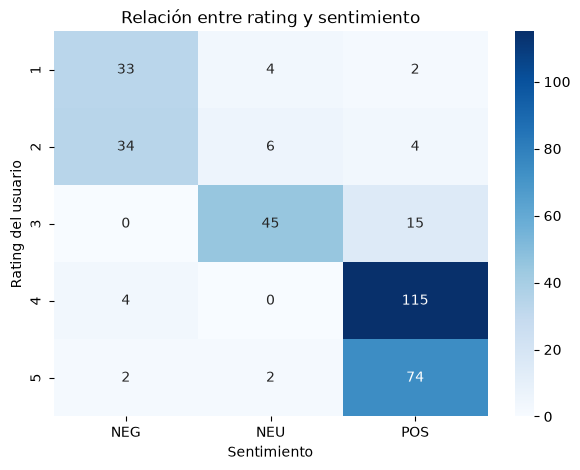

In [17]:
# ==========================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ==========================================
from pysentimiento import create_analyzer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 2. INICIALIZACIÓN Y FUNCIONES
# ==========================================
# Inicializamos el analizador de sentimientos en español
analyzer = create_analyzer(task="sentiment", lang="es")

def obtener_sentimiento(texto):
    if pd.isna(texto) or str(texto).strip() == "":
        return None
    # Predecimos el sentimiento y devolvemos la etiqueta (POS, NEG, NEU)
    resultado = analyzer.predict(str(texto))
    return resultado.output

# ==========================================
# 3. CARGA Y PROCESAMIENTO DE DATOS
# ==========================================
# Cargamos el archivo CSV
df = pd.read_csv("reviews_hoteles.csv")

# Aplicamos la función a la columna correcta ("review")
df["sentimiento"] = df["review"].apply(obtener_sentimiento)

# ==========================================
# 4. CREACIÓN DE LA TABLA CRUZADA
# ==========================================
tabla = pd.crosstab(
    df["rating_usuario"],
    df["sentimiento"]
)
print("Tabla cruzada generada:\n", tabla)

# ==========================================
# 5. VISUALIZACIÓN (HEATMAP)
# ==========================================
plt.figure(figsize=(7, 5))

sns.heatmap(
    tabla,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Relación entre rating y sentimiento")
plt.xlabel("Sentimiento")
plt.ylabel("Rating del usuario")
plt.show()

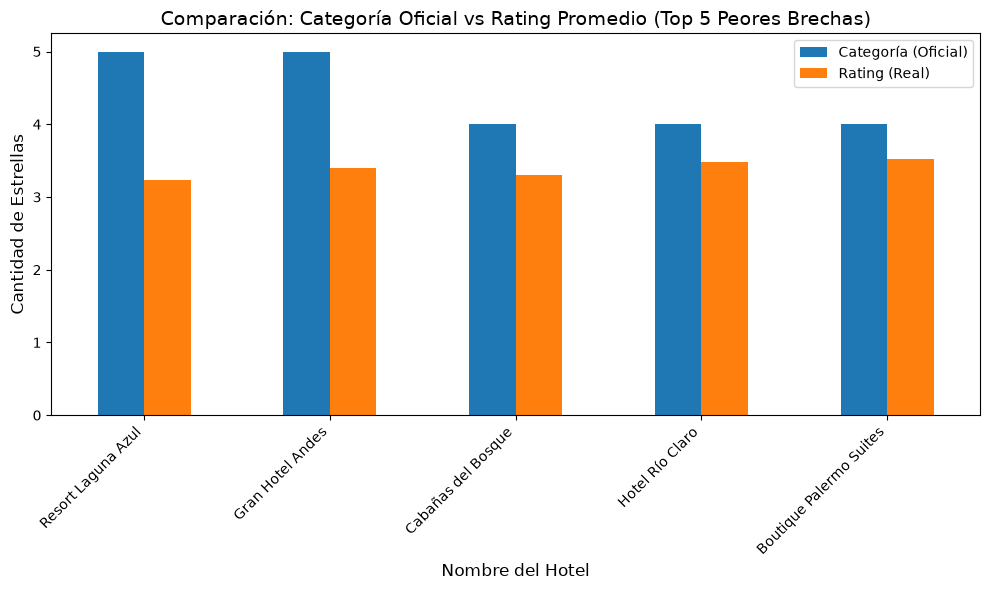

In [ ]:
# Tu codigo acá




import matplotlib.pyplot as plt

# 1. Tomamos solo los 5 hoteles con la mayor brecha (para que el gráfico no se sature)
# Usamos el dataframe 'hoteles_mayor_brecha_negativa' que creaste en el paso anterior
top_5_hoteles = hoteles_mayor_brecha_negativa.head(5)

# 2. Preparamos la tabla para el gráfico
# Ponemos el nombre del hotel como "índice" (el eje X) y nos quedamos solo con las dos columnas numéricas a comparar
datos_grafico = top_5_hoteles.set_index('hotel')[['categoria_hotel', 'rating_promedio']]

# 3. Creamos el gráfico de barras
# kind='bar' crea barras verticales. Pandas automáticamente agrupa las columnas lado a lado.
datos_grafico.plot(kind='bar', figsize=(10, 6), color=['#1f77b4', '#ff7f0e'])

# 4. Agregamos detalles para que se vea profesional
plt.title('Comparación: Categoría Oficial vs Rating Promedio (Top 5 Peores Brechas)', fontsize=14)
plt.ylabel('Cantidad de Estrellas', fontsize=12)
plt.xlabel('Nombre del Hotel', fontsize=12)

# Inclinamos los nombres de los hoteles para que se lean bien
plt.xticks(rotation=45, ha='right')

# Personalizamos la leyenda
plt.legend(['Categoría (Oficial)', 'Rating (Real)'])

# Ajustamos los márgenes para que nada quede cortado y mostramos
plt.tight_layout()
plt.show

7. **Storytelling.** Con los resultados anteriores, escribir una conclusión de negocio de 3 a 5 oraciones dirigida a la cadena de hoteles. Debe basarse en los números encontrados, no en impresiones generales.

El análisis de texto confirma que las estrellas otorgadas por los usuarios reflejan su experiencia real.Se detectó una falla operativa crítica en las propiedades que ostentan las categorías más altas (4 y 5 estrellas).Los hoteles insignia, como Resort Laguna Azul, apenas logran alcanzar valoraciones reales de 3.5 puntos.

## Pistas
 
- Para el análisis de sentimiento, `pysentimiento` es una librería en Python con un modelo ya entrenado para español — no hace falta entrenar nada, se instala y se usa directo.
- `categoria_hotel` y `rating_usuario` son cosas distintas: una es fija por hotel, la otra varía por reseña. La consigna 5 depende de no confundirlas.
- Para "no coincide" en la consigna 3, primero hay que llevar el rating a la misma escala que devuelve el modelo de sentimiento (positivo / negativo / neutro).
- Conviene resolver la consigna 1 antes que la 2 — tener una idea de cómo se distribuye el rating ayuda a interpretar mejor los resultados del sentimiento después.